In [19]:
import datetime
print("Latest Changes:", datetime.datetime.now())

Latest Changes: 2026-04-17 14:29:09.867960


# Point 3

### Imports & Data Loading

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr, mannwhitneyu
from scipy.spatial.distance import pdist, squareform

In [21]:
sensor = pd.read_csv("data/sensor_hrv_filtered.csv")
survey = pd.read_csv("data/survey.csv")

In [22]:
# Cleaning Survey
survey["PHQ9"] = survey[["PHQ9_1","PHQ9_2","PHQ9_F"]].mean(axis=1)
survey["GAD7"] = survey[["GAD7_1","GAD7_2","GAD7_F"]].mean(axis=1)
survey["ISI"]  = survey[["ISI_1","ISI_2","ISI_F"]].mean(axis=1)

survey_clean = survey[["deviceId","PHQ9","GAD7","ISI","MEQ"]]

In [23]:
# Cleaning Sensor
sensor["datetime"] = pd.to_datetime(sensor["ts_start"], unit="ms")
sensor_clean = sensor[sensor["missingness_score"] <= 0.3].copy()

### Necessary Functions

In [24]:
def safe_ami(ts, max_lag=50, bins=20):
    if len(ts) < 50 or np.std(ts) == 0:
        return None

    hist = np.histogram(ts, bins=bins)[1]
    ts_binned = np.digitize(ts, hist)

    ami_values = []
    for lag in range(1, max_lag):
        x = ts_binned[:-lag]
        y = ts_binned[lag:]

        if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
            ami_values.append(0)
            continue

        ami_values.append(mutual_info_score(x, y))

    return np.array(ami_values)

In [25]:
def first_local_minimum(arr):
    if arr is None or len(arr) < 3:
        return 1
    for i in range(1, len(arr)-1):
        if arr[i] < arr[i-1] and arr[i] < arr[i+1]:
            return i + 1
    return np.argmin(arr) + 1

In [26]:
def compute_fnn(ts, tau, max_dim=8, rtol=10):
    fnn_vals = []
    N = len(ts)

    for m in range(1, max_dim):
        M = N - (m+1)*tau
        if M <= 10:
            break

        emb_m = np.array([ts[i:i+m*tau:tau] for i in range(M)])
        emb_m1 = np.array([ts[i:i+(m+1)*tau:tau] for i in range(M)])

        nbrs = NearestNeighbors(n_neighbors=2).fit(emb_m)
        dist, idx = nbrs.kneighbors(emb_m)

        fnn = 0
        for i in range(M):
            nn = idx[i,1]
            d_m = dist[i,1]
            d_m1 = np.linalg.norm(emb_m1[i] - emb_m1[nn])

            if d_m > 0 and (d_m1 - d_m)/d_m > rtol:
                fnn += 1

        fnn_vals.append(fnn / M)

    return fnn_vals

In [27]:
def takens(ts, m, tau):
    N = len(ts)
    M = N - (m-1)*tau
    return np.array([ts[i:i+m*tau:tau] for i in range(M)])

##### RQA functions

In [28]:
def recurrence_matrix(emb, eps):
    D = squareform(pdist(emb))
    return (D < eps).astype(int)

In [29]:
def choose_eps(emb, target_rr=0.03):
    return np.quantile(pdist(emb), target_rr)

In [30]:
def recurrence_rate(R):
    return np.mean(R)

In [31]:
def determinism(R, l_min=2):
    N = R.shape[0]
    det_points = 0
    total_rec = np.sum(R)

    for k in range(-N+1, N):
        diag = np.diag(R, k=k)
        length = 0

        for val in diag:
            if val == 1:
                length += 1
            else:
                if length >= l_min:
                    det_points += length
                length = 0

        if length >= l_min:
            det_points += length

    return det_points / (total_rec + 1e-8)

In [32]:
def complexity(emb):
    nbrs = NearestNeighbors(n_neighbors=2).fit(emb)
    d, _ = nbrs.kneighbors(emb)
    return np.mean(d[:,1])

### Main Loop and Results

In [33]:
results = []

for pid in sensor_clean["deviceId"].unique():

    df = sensor_clean[sensor_clean["deviceId"] == pid].sort_values("datetime")
    ts = df["rmssd"].dropna().values

    if len(ts) < 100:
        continue

    ts = (ts - np.mean(ts)) / (np.std(ts) + 1e-8)

    ami_vals = safe_ami(ts)
    tau = first_local_minimum(ami_vals)

    fnn_vals = compute_fnn(ts, tau)
    if len(fnn_vals) == 0:
        continue

    m = next((i+1 for i,v in enumerate(fnn_vals) if v < 0.01), 3)

    emb = takens(ts, m, tau)

    eps = choose_eps(emb)
    R = recurrence_matrix(emb, eps)

    rr = recurrence_rate(R)
    det = determinism(R)
    comp = complexity(emb)

    results.append([pid, comp, det, rr, emb])

In [34]:
results_df = pd.DataFrame(results, columns=["deviceId","complexity","DET","RR","emb"])
results_df = results_df.merge(survey_clean, on="deviceId")

In [35]:
print("CORRELATIONS")
print("PHQ9:", spearmanr(results_df["DET"], results_df["PHQ9"]))
print("GAD7:", spearmanr(results_df["DET"], results_df["GAD7"]))
print("ISI:",  spearmanr(results_df["DET"], results_df["ISI"]))

CORRELATIONS
PHQ9: SignificanceResult(statistic=np.float64(0.2911925127464717), pvalue=np.float64(0.04464227976395671))
GAD7: SignificanceResult(statistic=np.float64(0.3456722658044539), pvalue=np.float64(0.01610800917429325))
ISI: SignificanceResult(statistic=np.float64(0.3701873914825402), pvalue=np.float64(0.009601647970954369))


In [36]:
results_df["PHQ_group"] = pd.qcut(results_df["PHQ9"], q=2, labels=["low","high"])

low = results_df[results_df["PHQ_group"] == "low"]["DET"]
high = results_df[results_df["PHQ_group"] == "high"]["DET"]

print("\nGROUP DIFFERENCE (PHQ)")
print(mannwhitneyu(low, high))
print("means:", low.mean(), high.mean())


GROUP DIFFERENCE (PHQ)
MannwhitneyuResult(statistic=np.float64(186.0), pvalue=np.float64(0.0395118162411572))
means: 0.22160096473164115 0.26480568006219873


In [37]:
results_df["GAD7_group"] = pd.qcut(results_df["GAD7"], q=2, labels=["low","high"])

low = results_df[results_df["GAD7_group"] == "low"]["DET"]
high = results_df[results_df["GAD7_group"] == "high"]["DET"]

print("\nGROUP DIFFERENCE (GAD7)")
print(mannwhitneyu(low, high))
print("means:", low.mean(), high.mean())


GROUP DIFFERENCE (GAD7)
MannwhitneyuResult(statistic=np.float64(201.0), pvalue=np.float64(0.14462892974212088))
means: 0.22459512851118701 0.26941645494752386


In [38]:
results_df["ISI_group"] = pd.qcut(results_df["ISI"], q=2, labels=["low","high"])

low = results_df[results_df["ISI_group"] == "low"]["DET"]
high = results_df[results_df["ISI_group"] == "high"]["DET"]

print("\nGROUP DIFFERENCE (ISI)")
print(mannwhitneyu(low, high))
print("means:", low.mean(), high.mean())


GROUP DIFFERENCE (ISI)
MannwhitneyuResult(statistic=np.float64(212.0), pvalue=np.float64(0.12166609474435458))
means: 0.22799805902074927 0.25597385082053525


### Visualizations

Text(0.5, 1.0, 'DET by Depression Group')

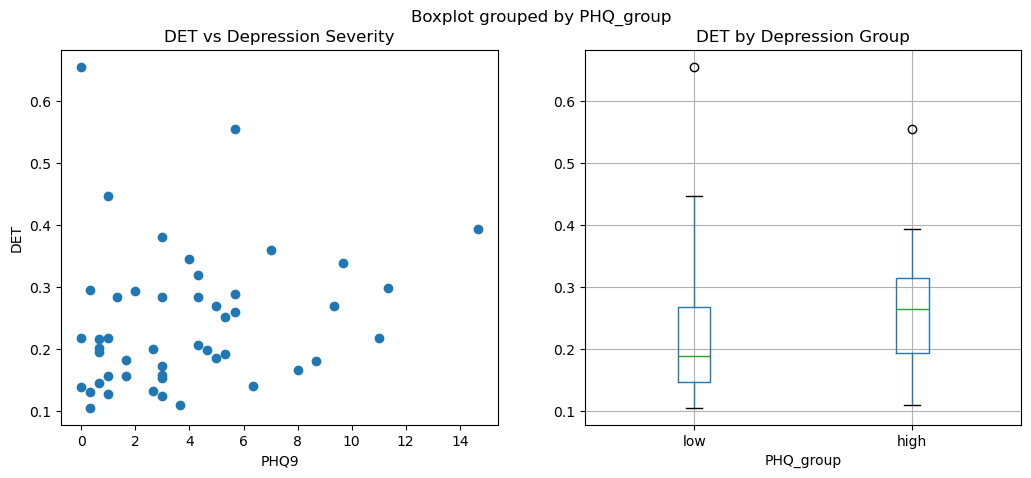

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot (left)
axes[0].scatter(results_df["PHQ9"], results_df["DET"])
axes[0].set_xlabel("PHQ9")
axes[0].set_ylabel("DET")
axes[0].set_title("DET vs Depression Severity")

# Boxplot (right)
results_df.boxplot(column="DET", by="PHQ_group", ax=axes[1])
axes[1].set_title("DET by Depression Group")


Text(0.5, 1.0, 'DET by Anxiety Group')

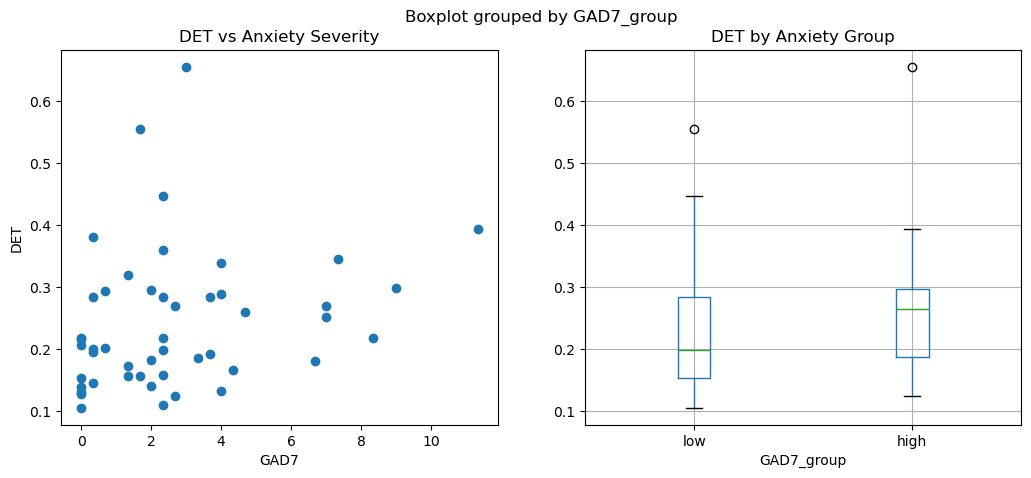

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot (left)
axes[0].scatter(results_df["GAD7"], results_df["DET"])
axes[0].set_xlabel("GAD7")
axes[0].set_ylabel("DET")
axes[0].set_title("DET vs Anxiety Severity")

# Boxplot (right)
results_df.boxplot(column="DET", by="GAD7_group", ax=axes[1])
axes[1].set_title("DET by Anxiety Group")


Text(0.5, 1.0, 'DET by Insomnia Group')

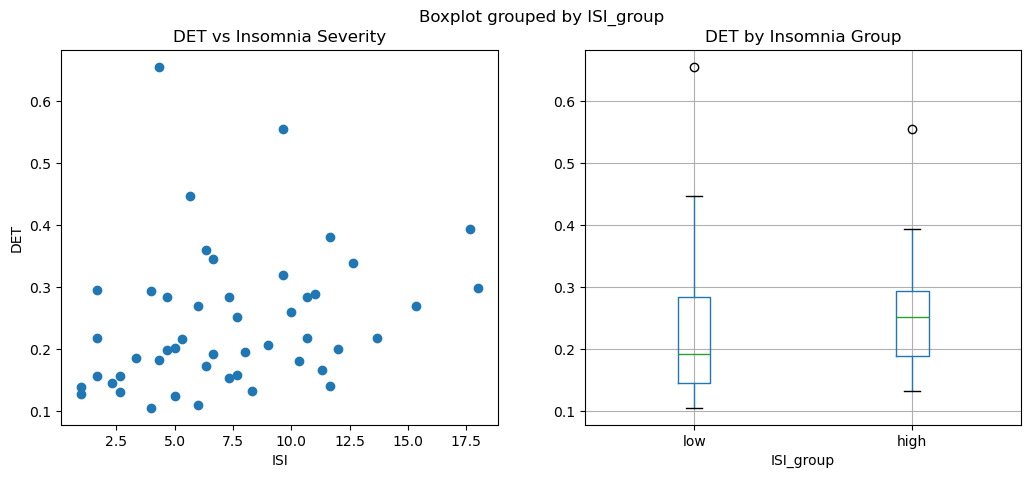

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot (left)
axes[0].scatter(results_df["ISI"], results_df["DET"])
axes[0].set_xlabel("ISI")
axes[0].set_ylabel("DET")
axes[0].set_title("DET vs Insomnia Severity")

# Boxplot (right)
results_df.boxplot(column="DET", by="ISI_group", ax=axes[1])
axes[1].set_title("DET by Insomnia Group")

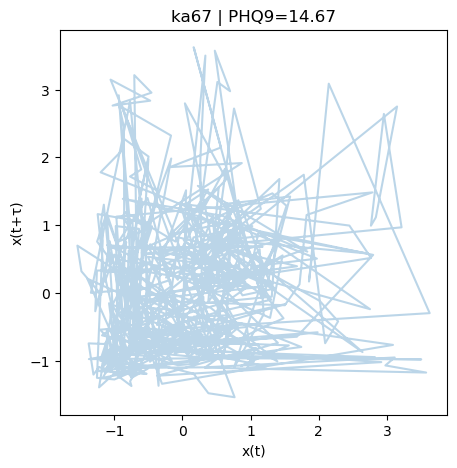

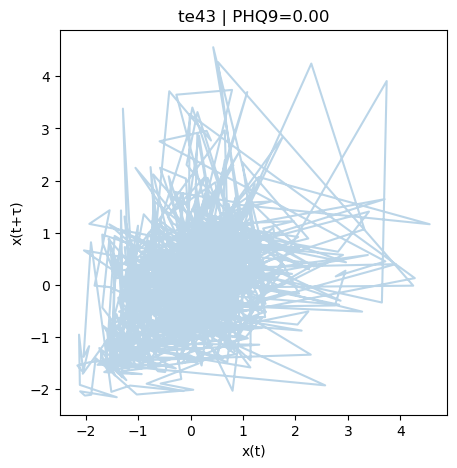

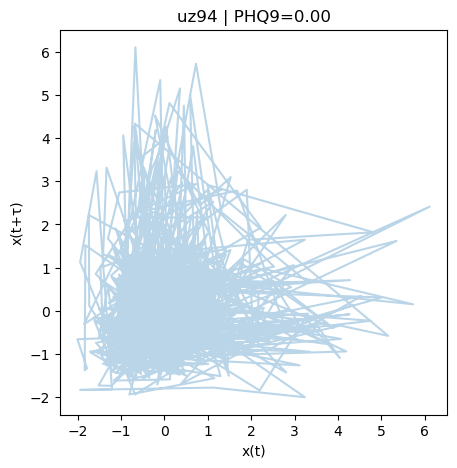

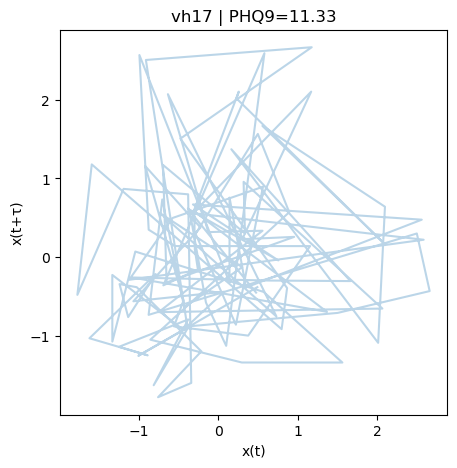

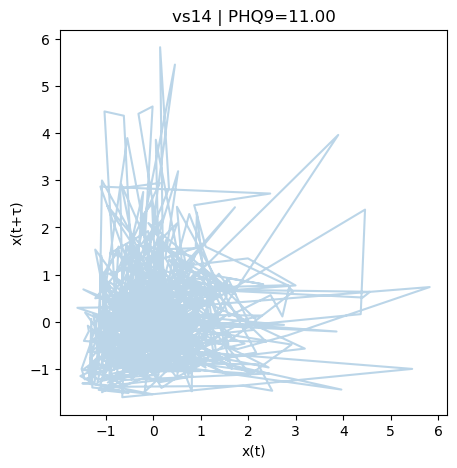

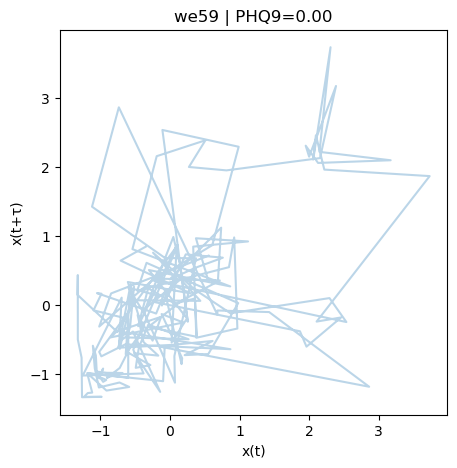

In [49]:
# Phase Space Reconstructions
high_ids = results_df.nlargest(3, "PHQ9")["deviceId"]
low_ids  = results_df.nsmallest(3, "PHQ9")["deviceId"]

for _, row in results_df.iterrows():
    if row["deviceId"] in list(high_ids) + list(low_ids):

        emb = row["emb"]

        plt.figure(figsize=(5,5))
        plt.plot(emb[:,0], emb[:,1], alpha=0.3)

        plt.title(f"{row['deviceId']} | PHQ9={row['PHQ9']:.2f}")
        plt.xlabel("x(t)")
        plt.ylabel("x(t+τ)")
        plt.show()

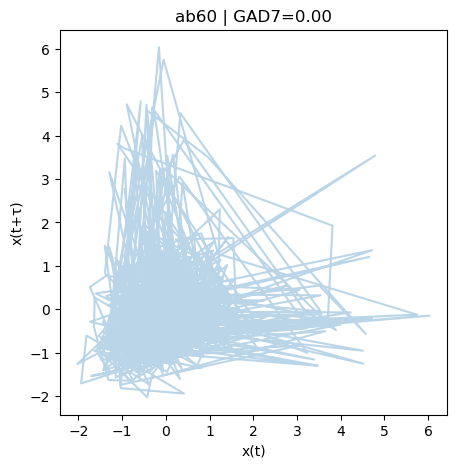

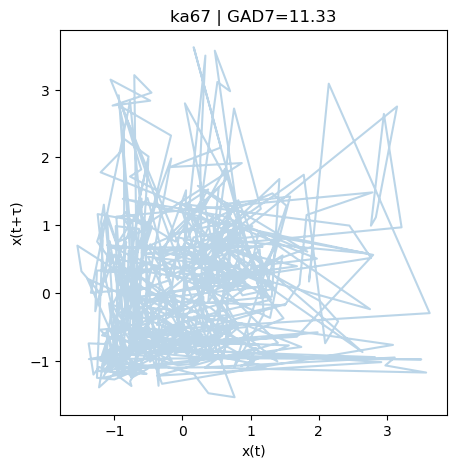

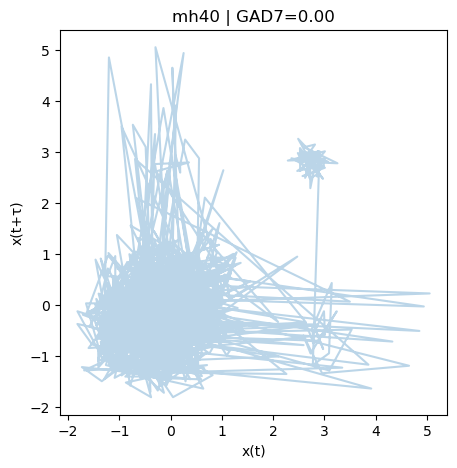

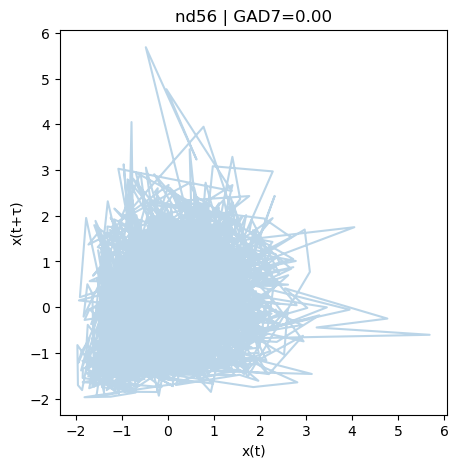

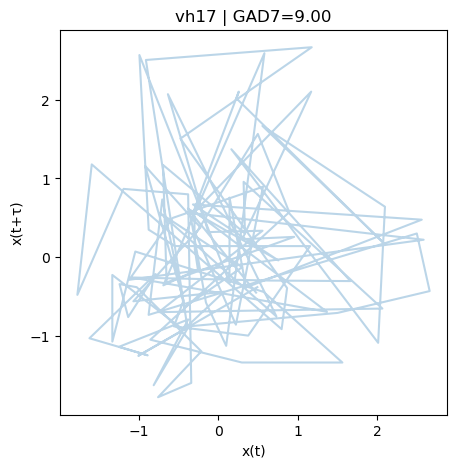

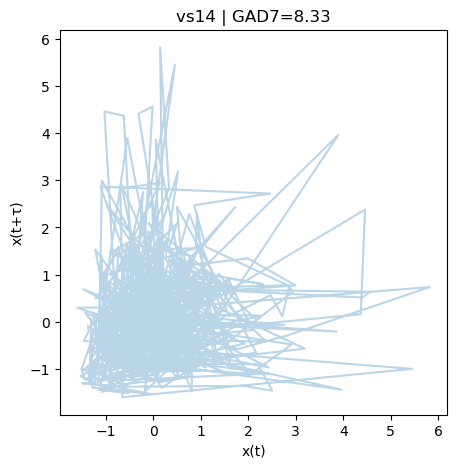

In [52]:
# Phase Space Reconstructions
high_ids = results_df.nlargest(3, "GAD7")["deviceId"]
low_ids  = results_df.nsmallest(3, "GAD7")["deviceId"]

for _, row in results_df.iterrows():
    if row["deviceId"] in list(high_ids) + list(low_ids):

        emb = row["emb"]

        plt.figure(figsize=(5,5))
        plt.plot(emb[:,0], emb[:,1], alpha=0.3)

        plt.title(f"{row['deviceId']} | GAD7={row['GAD7']:.2f}")
        plt.xlabel("x(t)")
        plt.ylabel("x(t+τ)")
        plt.show()

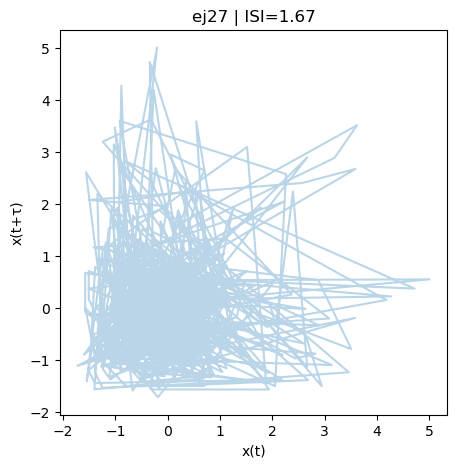

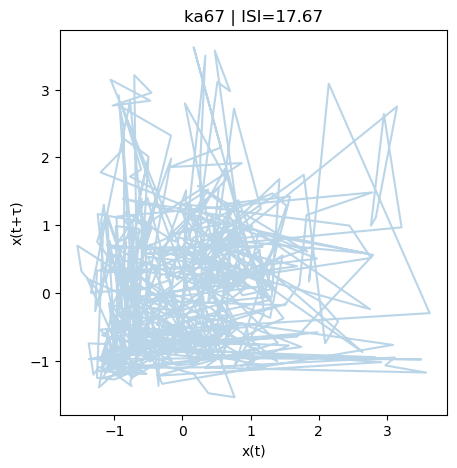

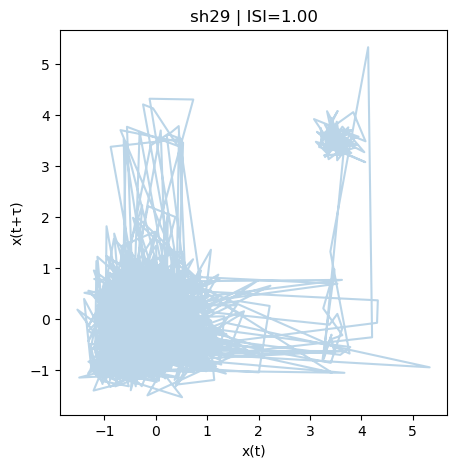

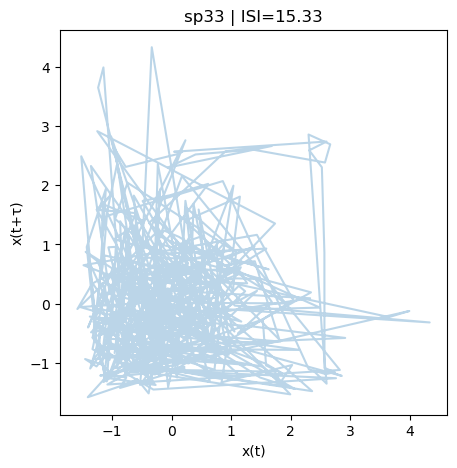

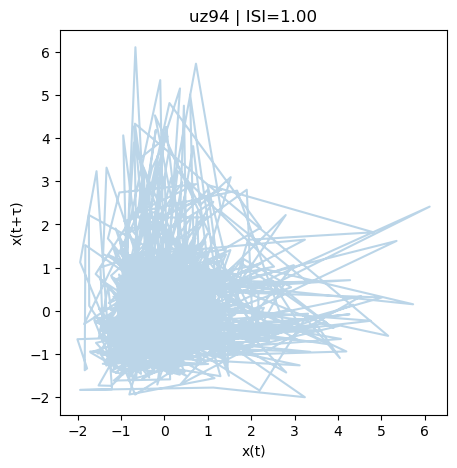

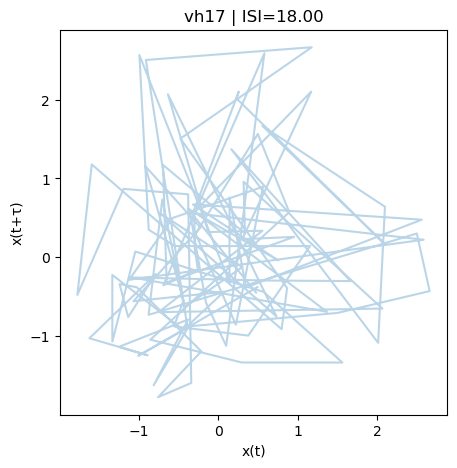

In [53]:
# Phase Space Reconstructions
high_ids = results_df.nlargest(3, "ISI")["deviceId"]
low_ids  = results_df.nsmallest(3, "ISI")["deviceId"]

for _, row in results_df.iterrows():
    if row["deviceId"] in list(high_ids) + list(low_ids):

        emb = row["emb"]

        plt.figure(figsize=(5,5))
        plt.plot(emb[:,0], emb[:,1], alpha=0.3)

        plt.title(f"{row['deviceId']} | ISI={row['ISI']:.2f}")
        plt.xlabel("x(t)")
        plt.ylabel("x(t+τ)")
        plt.show()